# Data Loading

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

#file_path = '/content/drive/MyDrive/Final_project_DHUB/Grouped_data.xlsx'  #Colab
file_path = 'D:\Saif\Final-project\Data_under_trial\Data_under_trial\Global E-Commerce Customer Purchase Prediction\global-e-commerce-customer-purchase-prediction/Grouped_data.xlsx'
file_path_sessions_table = 'D:\Saif\Final-project\Data_under_trial\Data_under_trial\Global E-Commerce Customer Purchase Prediction\global-e-commerce-customer-purchase-prediction\sessions.csv'
df_sessions = pd.read_csv(file_path_sessions_table)
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)


['transactions', 'train', 'test', 'sessions', 'marketing_campaigns', 'geo_data', 'customers']


In [ ]:
file_path_raw = r"D:\Saif\Final-project\Data_under_trial\Data_under_trial\Global E-Commerce Customer Purchase Prediction\global-e-commerce-customer-purchase-prediction"

In [ ]:
dfs = {}
for sheet_name in xls.sheet_names:
    dfs[sheet_name] = pd.read_excel(file_path, sheet_name=sheet_name)
print(dfs.keys())

dict_keys(['transactions', 'train', 'test', 'sessions', 'marketing_campaigns', 'geo_data', 'customers'])


In [ ]:
df_customers = dfs["customers"]
df_transactions = dfs["transactions"]
#df_sessions = dfs["sessions"]
df_train = dfs["train"]
df_test = dfs["test"]
df_campaigns = dfs["marketing_campaigns"]
df_geo = dfs["geo_data"]

dfs_list = [
    "df_customers",
    "df_transactions",
    "df_sessions",
    "df_train",
    "df_test",
    "df_campaigns",
    "df_geo",]

In [ ]:
file_path_sessions = 'D:\Saif\Final-project\Data_under_trial\Data_under_trial\Global E-Commerce Customer Purchase Prediction\global-e-commerce-customer-purchase-prediction\sessions.csv'

In [ ]:
df_sessions = pd.read_csv(file_path_sessions)

# Data Cleaning

In [ ]:
df_sessions.head(5)

,session_id,customer_id,session_timestamp,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region
0,0,98947,2022-01-26,699.425135,2.0,4,0,organic,Desktop,105,region_74
1,1,180169,2023-05-19,127.086666,8.0,2,FALSE,organic,mobile,155,region_15
2,2,196195,2022-03-24,99.648727,3.0,3,1,Organic,Desktop,183,region_37
3,3,92468,2023-05-20,1.660842,3.0,2,No,ads,desktop,39,region_52
4,4,21053,2024-07-06,867.507773,5.0,0,FALSE,organic,Mobile,139,region_72


In [ ]:
df_sessions["bounce_flag"] = df_sessions["bounce_flag"].map({
    '1': 1,
    '0': 0,
    "TRUE": 1,
    "FALSE": 0,
    "Yes": 1,
    "No": 0
})

In [ ]:
df_sessions = df_sessions.rename(columns={
    "session_timestamp": "session_date"
})
df_sessions["session_date"] = pd.to_datetime(df_sessions["session_date"])

In [ ]:
df_sessions.isnull().sum()

session_id               0
customer_id              0
session_date             0
session_duration         0
pages_viewed        100000
cart_additions           0
bounce_flag              0
traffic_source           0
device_type              0
campaign_id              0
geo_ip_region            0
dtype: int64

In [ ]:
df_sessions["pages_viewed"] = df_sessions["pages_viewed"].fillna(0).astype(int)
df_sessions["device_type"] = df_sessions["device_type"].replace("desktop", "Desktop")
df_sessions["device_type"].value_counts(normalize = True)

device_type
Desktop    0.400674
Mobile     0.200339
mobile     0.199843
TABLET     0.199145
Name: proportion, dtype: float64

In [ ]:
df_sessions.isnull().sum()

session_id          0
customer_id         0
session_date        0
session_duration    0
pages_viewed        0
cart_additions      0
bounce_flag         0
traffic_source      0
device_type         0
campaign_id         0
geo_ip_region       0
dtype: int64

In [ ]:
df_sessions = df_sessions.convert_dtypes()

In [ ]:
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 11 columns):
 #   Column            Dtype         
---  ------            -----         
 0   session_id        Int64         
 1   customer_id       Int64         
 2   session_date      datetime64[ns]
 3   session_duration  Float64       
 4   pages_viewed      Int64         
 5   cart_additions    Int64         
 6   bounce_flag       Int64         
 7   traffic_source    string        
 8   device_type       string        
 9   campaign_id       Int64         
 10  geo_ip_region     string        
dtypes: Float64(1), Int64(6), datetime64[ns](1), string(3)
memory usage: 181.2 MB


In [ ]:
df_sessions.head(5)

,session_id,customer_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region
0,0,98947,2022-01-26,699.425135,2,4,0,organic,Desktop,105,region_74
1,1,180169,2023-05-19,127.086666,8,2,0,organic,mobile,155,region_15
2,2,196195,2022-03-24,99.648727,3,3,1,Organic,Desktop,183,region_37
3,3,92468,2023-05-20,1.660842,3,2,0,ads,Desktop,39,region_52
4,4,21053,2024-07-06,867.507773,5,0,0,organic,Mobile,139,region_72


In [ ]:
dfs["sessions"] = df_sessions

In [ ]:
df_sessions.head(3)

,session_id,customer_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region
0,0,98947,2022-01-26,699.425135,2,4,0,organic,Desktop,105,region_74
1,1,180169,2023-05-19,127.086666,8,2,0,organic,mobile,155,region_15
2,2,196195,2022-03-24,99.648727,3,3,1,Organic,Desktop,183,region_37


# Data Combiniing


In [ ]:
dfs["customers"].head(5)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,customer_tier,credit_limit
0,0,73,US,region_50,2022-08-02,0.244,0.660207,0.238170,4.837508,REF_904704,Bronze,10966
1,1,47,US,region_3,2023-06-14,0.196,0.257952,0.332332,4.447899,REF_183413,Silver,14189
2,2,67,US,region_54,2024-01-06,0.326,0.157587,0.002592,3.641375,REF_535074,Platinum,15043
3,3,21,US,region_82,2023-12-07,0.116,0.234343,0.246847,3.935681,REF_754240,Silver,8484
4,4,35,IN,region_33,2023-10-16,0.371,0.230297,0.127043,3.966327,REF_794359,Silver,13128


In [ ]:
#no duplicates and no null already cleand in excel step
print(dfs["customers"].duplicated().sum())
sum(dfs["customers"].isnull().sum())

0


0

In [ ]:
for name in dfs_list :
    globals()[name] = globals()[name].convert_dtypes()

In [ ]:
for i in dfs_list :
    print(f"{i} \n")
    print(f"\n {globals()[i].info()}")
    print("-----------------------------")

df_customers 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          200000 non-null  Int64         
 1   age                  200000 non-null  Int64         
 2   country_code         200000 non-null  string        
 3   region               200000 non-null  string        
 4   signup_date          200000 non-null  datetime64[ns]
 5   loyalty_score        200000 non-null  Float64       
 6   email_open_rate      200000 non-null  Float64       
 7   discount_usage_rate  200000 non-null  Float64       
 8   avg_review_score     200000 non-null  Float64       
 9   referral_code        200000 non-null  string        
 10  customer_tier        200000 non-null  string        
 11  credit_limit         200000 non-null  Int64         
dtypes: Float64(4), Int64(3), datetime64[ns](1), string(4)
mem

In [ ]:
df_customers = dfs["customers"].copy()

# 1) customers ↔ transactions
df = df_customers.merge(
    dfs["transactions"],
    on="customer_id",
    how="inner"
)

# 2) customers ↔ sessions
df = df.merge(
    dfs["sessions"],
    on="customer_id",
    how="inner"
)

# 3) sessions ↔ geo_data (via geo_ip_region)
df = df.merge(
    dfs["geo_data"],
    left_on="geo_ip_region",
    right_on="geo_ip_region",
    how="inner"
)

# 4) sessions ↔ marketing_campaigns (via campaign_id)
df = df.merge(
    dfs["marketing_campaigns"],
    left_on="campaign_id",
    right_on="campaign_id",
    how="inner"
)

# 5) customers ↔ train (via customer_id)
df = df.merge(
    dfs["train"],
    left_on="customer_id",
    right_on="customer_id",
    how="inner"
)

In [ ]:
df.head(5)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,...,average_income,urban_ratio,internet_penetration,region_tier,campaign_type,campaign_budget,region_target,start_date,end_date,target
0,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,...,46613.355493,0.455715,0.688698,Tier3,Search,114573,region_36,2022-03-16,2022-05-17,0
1,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,...,10703.823439,0.694179,0.855785,Tier1,Search,413704,region_13,2022-06-24,2022-08-07,0
2,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,...,52570.524218,0.310782,0.896956,Tier1,Social,16949,region_23,2022-12-22,2023-02-16,0
3,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,...,30077.209267,0.326504,0.676151,Tier3,Social,157820,region_96,2022-08-17,2022-10-09,0
4,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,...,39469.203592,0.360889,0.823497,Tier3,Display,54247,region_24,2022-09-06,2022-10-19,0


In [ ]:
df.shape

(4000472, 40)

In [ ]:
df.isnull().sum()

customer_id             0
age                     0
country_code            0
region                  0
signup_date             0
loyalty_score           0
email_open_rate         0
discount_usage_rate     0
avg_review_score        0
referral_code           0
customer_tier           0
credit_limit            0
transaction_id          0
transaction_date        0
order_value             0
items_count             0
payment_method          0
discount_applied        0
shipping_speed          0
high_value_flag         0
session_id              0
session_date            0
session_duration        0
pages_viewed            0
cart_additions          0
bounce_flag             0
traffic_source          0
device_type             0
campaign_id             0
geo_ip_region           0
average_income          0
urban_ratio             0
internet_penetration    0
region_tier             0
campaign_type           0
campaign_budget         0
region_target           0
start_date              0
end_date    

In [ ]:
df.to_csv(f"{file_path_raw}\Cleaned_Grouped_Data.csv", index=False)

# Saving Data for Power bi

In [ ]:
save_path = r"D:\Saif\Final-project\Data_under_trial\Data_under_trial\Global E-Commerce Customer Purchase Prediction\global-e-commerce-customer-purchase-prediction\Cleaned_datasets"

df_sessions.to_csv(f"{save_path}\sessions.csv" , index =False )

for name, data in dfs.items():
    data = data.convert_dtypes()
    data.to_csv(f"{save_path}\\{name}.csv", index=False)

In [ ]:
# Randomly keep 20% of rows
df_sessions_sample = df_sessions.sample(
    frac=0.20,
    random_state=42
)

# Save to CSV
df_sessions_sample.to_csv(
    "df_sessions_20pct.csv",
    index=False
)

# Data Exploration

In [ ]:
df = pd.read_csv(f"{file_path_raw}\\Cleaned_Grouped_Data.csv")
pd.set_option("display.max_columns", None)

df.head(5)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,customer_tier,credit_limit,transaction_id,transaction_date,order_value,items_count,payment_method,discount_applied,shipping_speed,high_value_flag,session_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region,average_income,urban_ratio,internet_penetration,region_tier,campaign_type,campaign_budget,region_target,start_date,end_date,target
0,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,38690,2023-11-30,1317.053930,5,3,1,organic,TABLET,72,region_21,46613.355493,0.455715,0.688698,Tier3,Search,114573,region_36,2022-03-16,2022-05-17,0
1,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,136618,2022-03-30,77.391999,10,2,1,ads,Mobile,123,region_74,10703.823439,0.694179,0.855785,Tier1,Search,413704,region_13,2022-06-24,2022-08-07,0
2,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,774178,2024-05-23,893.343800,13,3,0,ads,Mobile,35,region_41,52570.524218,0.310782,0.896956,Tier1,Social,16949,region_23,2022-12-22,2023-02-16,0
3,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,829895,2023-03-15,106.053968,6,1,0,ads,Desktop,153,region_38,30077.209267,0.326504,0.676151,Tier3,Social,157820,region_96,2022-08-17,2022-10-09,0
4,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,848862,2023-05-21,714.065687,5,2,0,SOCIAL,Desktop,151,region_92,39469.203592,0.360889,0.823497,Tier3,Display,54247,region_24,2022-09-06,2022-10-19,0


In [ ]:
df.shape

(4000472, 40)

In [ ]:
df["target"].value_counts(normalize =True)

target
0    0.798108
1    0.201892
Name: proportion, dtype: float64

In [ ]:
date_cols = ["transaction_date", "session_date", "start_date", "end_date","signup_date"]

df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [ ]:
df = df.convert_dtypes()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000472 entries, 0 to 4000471
Data columns (total 40 columns):
 #   Column                Dtype         
---  ------                -----         
 0   customer_id           Int64         
 1   age                   Int64         
 2   country_code          string        
 3   region                string        
 4   signup_date           datetime64[ns]
 5   loyalty_score         Float64       
 6   email_open_rate       Float64       
 7   discount_usage_rate   Float64       
 8   avg_review_score      Float64       
 9   referral_code         string        
 10  customer_tier         string        
 11  credit_limit          Int64         
 12  transaction_id        Int64         
 13  transaction_date      datetime64[ns]
 14  order_value           Int64         
 15  items_count           Int64         
 16  payment_method        string        
 17  discount_applied      Int64         
 18  shipping_speed        string        
 19  

In [ ]:
df.describe()

,customer_id,age,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,credit_limit,transaction_id,transaction_date,order_value,items_count,discount_applied,session_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,campaign_id,average_income,urban_ratio,internet_penetration,campaign_budget,start_date,end_date,target
count,4000472.0,4000472.0,4000472,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472,4000472.0,4000472.0,4000472.0,4000472.0,4000472,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472.0,4000472,4000472,4000472.0
mean,99899.375866,43.661738,2023-02-03 08:31:29.913789696,0.285214,0.331635,0.332856,3.998409,10495.805669,250207.71003,2023-05-15 11:28:20.482543360,120.110096,2.999525,0.500209,1000040.611118,2023-05-15 11:14:25.870626560,477.333272,5.704552,1.999903,0.499381,99.602489,48454.257537,0.615863,0.758862,248529.128944,2022-07-12 15:56:42.700082688,2022-09-23 21:55:44.991689216,0.201892
min,0.0,0.0,2022-01-01 00:00:00,0.001,0.001563,0.000311,1.569531,1000.0,0.0,2022-01-01 00:00:00,0.0,0.0,0.0,0.0,2022-01-01 00:00:00,0.000153,0.0,0.0,0.0,0.0,10703.823439,0.30329,0.507574,11062.0,2022-01-01 00:00:00,2022-02-25 00:00:00,0.0
25%,50085.0,30.0,2022-07-19 00:00:00,0.161,0.209793,0.170917,3.661589,5773.0,125072.0,2022-09-07 00:00:00,34.0,2.0,0.0,500562.0,2022-09-07 00:00:00,116.659207,4.0,1.0,0.0,50.0,40990.419651,0.455715,0.640405,121317.0,2022-04-16 00:00:00,2022-06-24 00:00:00,0.0
50%,99890.0,44.0,2023-02-02 00:00:00,0.264,0.31416,0.305652,3.995966,10495.0,250201.0,2023-05-16 00:00:00,83.0,3.0,1.0,999586.5,2023-05-15 00:00:00,281.675244,6.0,2.0,0.0,100.0,48265.275764,0.626741,0.765896,257666.0,2022-07-08 00:00:00,2022-09-24 00:00:00,0.0
75%,149726.0,59.0,2023-08-22 00:00:00,0.388,0.433466,0.469247,4.336936,15227.0,375509.0,2024-01-20 00:00:00,166.0,4.0,1.0,1500067.5,2024-01-21 00:00:00,565.711644,7.0,3.0,1.0,150.0,57450.712295,0.749732,0.889458,375340.0,2022-10-18 00:00:00,2022-12-26 00:00:00,0.0
max,199999.0,74.0,2024-03-10 00:00:00,0.929,0.951867,0.982597,6.389763,19999.0,499999.0,2024-09-26 00:00:00,1670.0,14.0,1.0,1999999.0,2024-09-26 00:00:00,76199.234151,21.0,13.0,1.0,199.0,77784.172768,0.940673,0.985126,495450.0,2022-12-30 00:00:00,2023-04-21 00:00:00,1.0
std,57691.604453,18.895259,NaN,0.159416,0.168379,0.200956,0.499936,5467.967625,144436.329179,NaN,120.419506,1.733884,0.5,577327.791351,NaN,1191.128916,2.721658,1.414198,0.5,57.719488,13545.94175,0.186315,0.140264,140889.79121,NaN,NaN,0.401412


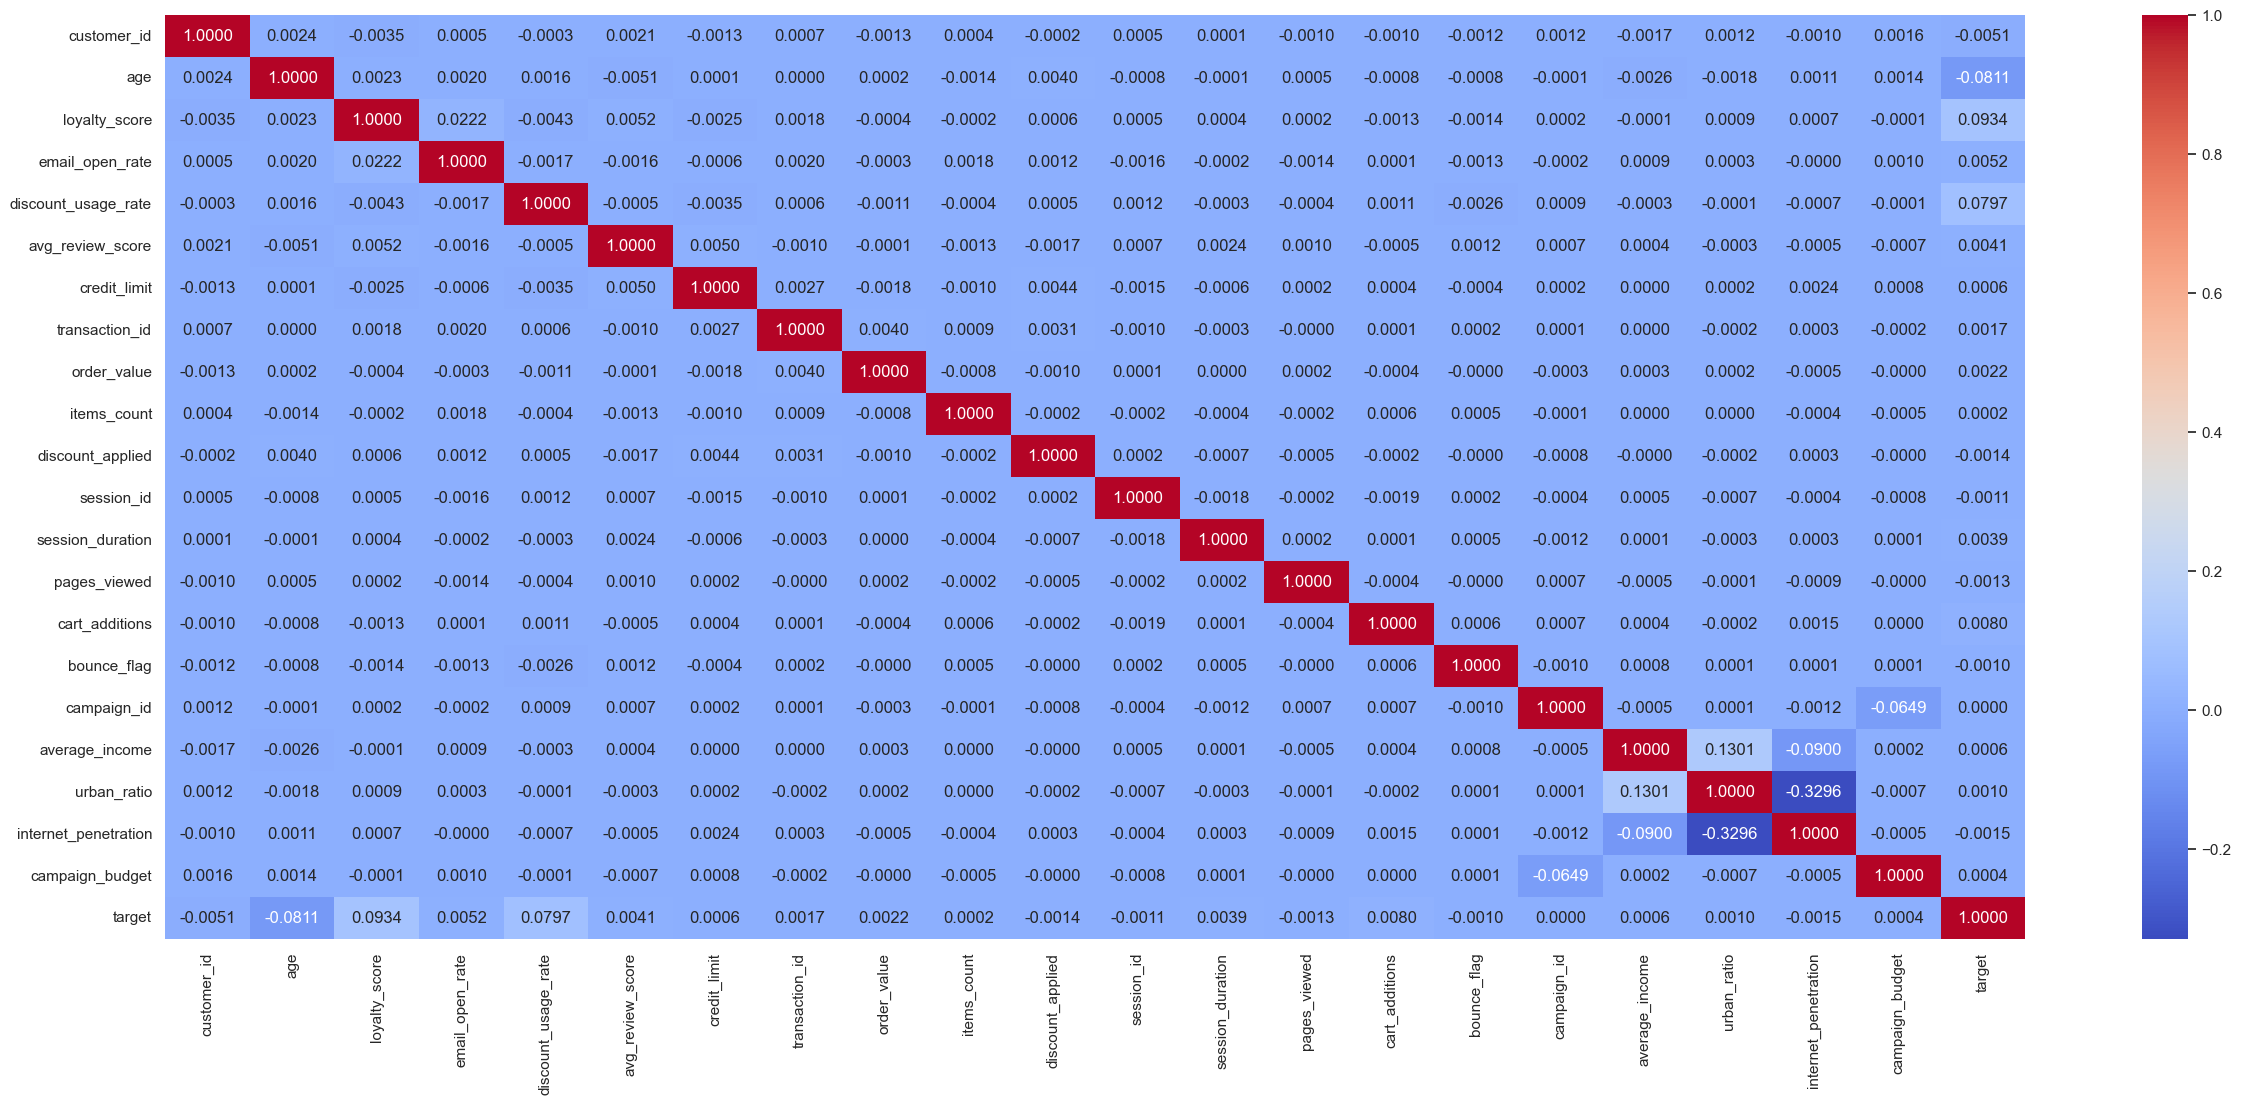

In [ ]:
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(30, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".4f")
plt.show()

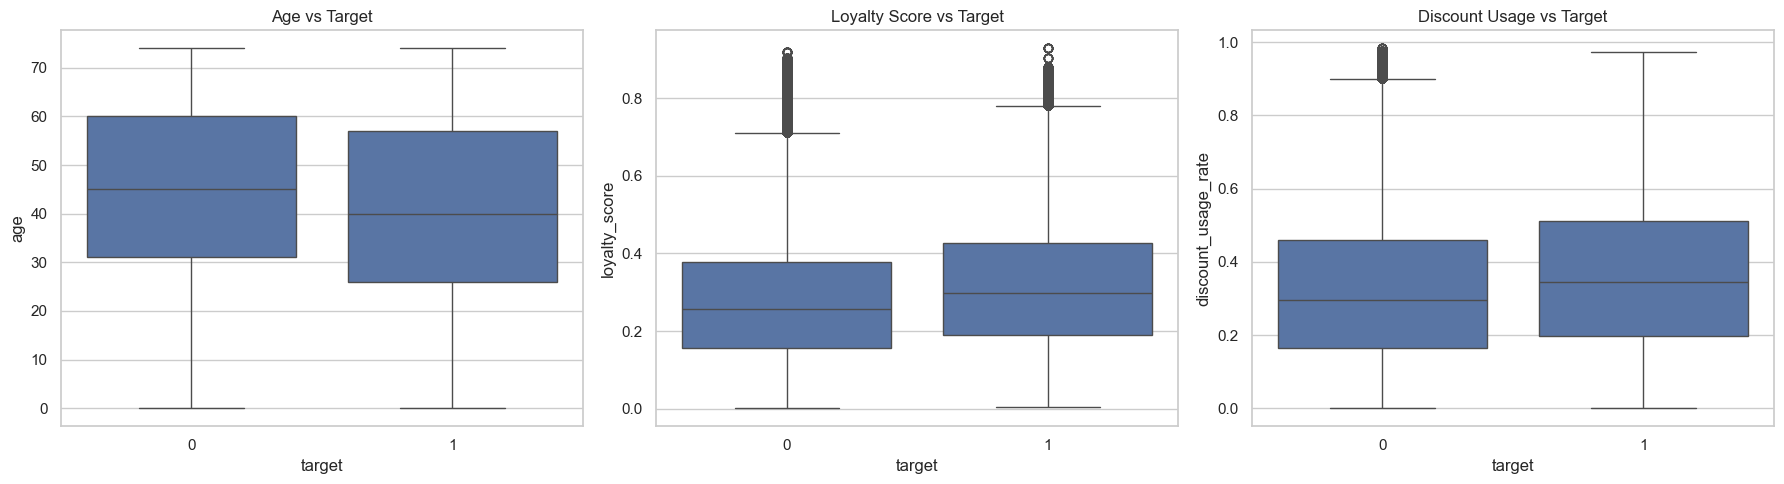

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='target', y='age', ax=axes[0])
axes[0].set_title('Age vs Target')

sns.boxplot(data=df, x='target', y='loyalty_score', ax=axes[1])
axes[1].set_title('Loyalty Score vs Target')

sns.boxplot(data=df, x='target', y='discount_usage_rate', ax=axes[2])
axes[2].set_title('Discount Usage vs Target')

plt.tight_layout()
plt.show()

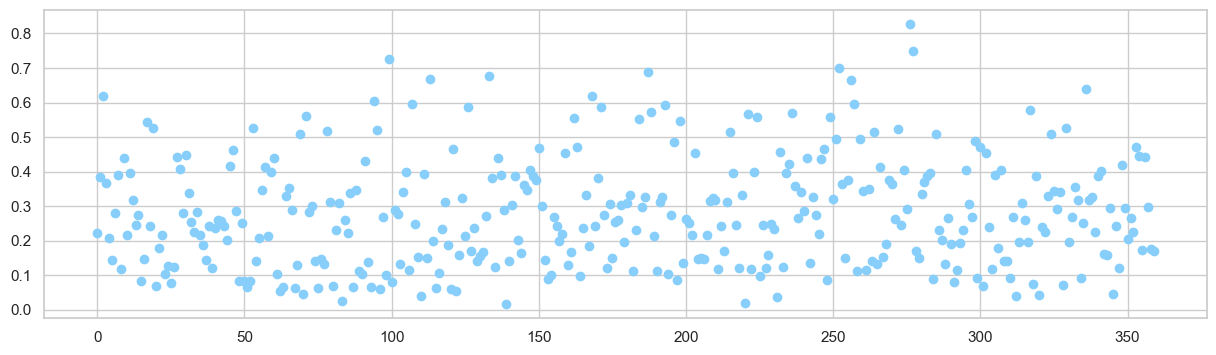

In [ ]:
down_sampled = df.sample(frac= 0.00009) # take small fraction for better visualization
loyalty_score_nbins = down_sampled.loyalty_score
loyalty_score_nbins = range(len(loyalty_score_nbins))

plt.figure(figsize = (15,4))
plt.scatter(loyalty_score_nbins , down_sampled.loyalty_score,c="lightskyblue")
plt.show()

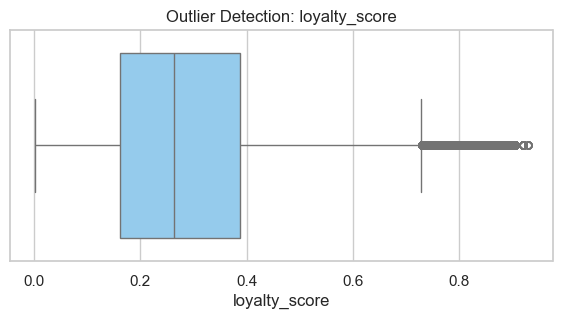

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 3))

sns.boxplot(
    data=df,
    x="loyalty_score",
    color="lightskyblue",
    fliersize=5  # This controls the size of the outlier dots
)
plt.title("Outlier Detection: loyalty_score")

# 5. Display the plot
plt.show()

In [ ]:
corr_target = (
    df.corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

print(corr_target)

target                  1.000000
loyalty_score           0.093350
discount_usage_rate     0.079691
cart_additions          0.008006
email_open_rate         0.005155
avg_review_score        0.004053
session_duration        0.003916
order_value             0.002234
transaction_id          0.001675
urban_ratio             0.001011
credit_limit            0.000584
average_income          0.000583
campaign_budget         0.000432
items_count             0.000248
campaign_id             0.000001
bounce_flag            -0.000978
session_id             -0.001121
pages_viewed           -0.001274
discount_applied       -0.001436
internet_penetration   -0.001513
customer_id            -0.005066
age                    -0.081098
Name: target, dtype: float64


In [ ]:
from sklearn.metrics import mutual_info_score

categorical_features = df.select_dtypes(include="string").columns.tolist()

def calculate_mi(series):
    return mutual_info_score(series, df.target)

df_mi = df[categorical_features].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')

In [ ]:
df.head(1)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,customer_tier,credit_limit,transaction_id,transaction_date,order_value,items_count,payment_method,discount_applied,shipping_speed,high_value_flag,session_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region,average_income,urban_ratio,internet_penetration,region_tier,campaign_type,campaign_budget,region_target,start_date,end_date,target
0,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,38690,2023-11-30,1317.05393,5,3,1,organic,TABLET,72,region_21,46613.355493,0.455715,0.688698,Tier3,Search,114573,region_36,2022-03-16,2022-05-17,0


In [ ]:
df_mi.head(15).round(6)

,MI
referral_code,0.472377
region,0.000421
customer_tier,0.000043
geo_ip_region,0.000037
region_target,0.000034
country_code,0.000008
payment_method,0.000007
shipping_speed,0.000004
campaign_type,0.000004
traffic_source,0.000002


**average_income, urban_ratio, and internet_penetration all have correlations near 0.001. This implies that where the customer lives doesn't really matter—only their behavior on the website matters**

## Feature Engineering

In [ ]:
df.head(3)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,customer_tier,credit_limit,transaction_id,transaction_date,order_value,items_count,payment_method,discount_applied,shipping_speed,high_value_flag,session_id,session_date,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region,average_income,urban_ratio,internet_penetration,region_tier,campaign_type,campaign_budget,region_target,start_date,end_date,target
0,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,38690,2023-11-30,1317.05393,5,3,1,organic,TABLET,72,region_21,46613.355493,0.455715,0.688698,Tier3,Search,114573,region_36,2022-03-16,2022-05-17,0
1,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,136618,2022-03-30,77.391999,10,2,1,ads,Mobile,123,region_74,10703.823439,0.694179,0.855785,Tier1,Search,413704,region_13,2022-06-24,2022-08-07,0
2,0,73,US,region_50,2022-08-02,0.244,0.660207,0.23817,4.837508,REF_904704,Bronze,10966,169754,2023-04-15,220,5,paypal,0,overnight,No,774178,2024-05-23,893.3438,13,3,0,ads,Mobile,35,region_41,52570.524218,0.310782,0.896956,Tier1,Social,16949,region_23,2022-12-22,2023-02-16,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000472 entries, 0 to 4000471
Data columns (total 40 columns):
 #   Column                Dtype         
---  ------                -----         
 0   customer_id           Int64         
 1   age                   Int64         
 2   country_code          string        
 3   region                string        
 4   signup_date           datetime64[ns]
 5   loyalty_score         Float64       
 6   email_open_rate       Float64       
 7   discount_usage_rate   Float64       
 8   avg_review_score      Float64       
 9   referral_code         string        
 10  customer_tier         string        
 11  credit_limit          Int64         
 12  transaction_id        Int64         
 13  transaction_date      datetime64[ns]
 14  order_value           Int64         
 15  items_count           Int64         
 16  payment_method        string        
 17  discount_applied      Int64         
 18  shipping_speed        string        
 19  

In [ ]:
unique_transactions = df[['customer_id', 'transaction_id', 'transaction_date', 'order_value']].drop_duplicates()

In [ ]:
df["Intent_score"] = df["cart_additions"] * df["email_open_rate"]

In [ ]:
rfm = unique_transactions.groupby('customer_id').agg(
    Frequency=('transaction_id', 'count'),  # Count of unique orders
    Monetary=('order_value', 'sum'),        # True sum of money spent
    Last_Purchase_Date=('transaction_date', 'max')
).reset_index()

In [ ]:
snapshot_date = unique_transactions['transaction_date'].max() + pd.Timedelta(days=1)
rfm['Recency'] = (snapshot_date - rfm['Last_Purchase_Date']).dt.days
rfm = rfm.drop(columns=['Last_Purchase_Date'])

In [ ]:
campaigns = df.groupby('customer_id').agg(
    Total_Campaigns_Seen=('campaign_id', 'nunique')
).reset_index()

In [ ]:
profile_cols = [
    'customer_id', 'age', 'loyalty_score', 'customer_tier',
    'credit_limit', 'target', 'average_income','discount_usage_rate','Intent_score' # Add any others you want to keep
]

In [ ]:
customer_profiles = df[profile_cols].drop_duplicates(subset=['customer_id'])

In [ ]:
profile_ml_dataset = customer_profiles.merge(rfm, on='customer_id', how='left')
profile_ml_dataset = profile_ml_dataset.merge(campaigns, on='customer_id', how='left')

In [ ]:
df = profile_ml_dataset[
["customer_id",
  "age",
  "loyalty_score",
  "customer_tier",
  "credit_limit",
  "average_income",
  "Total_Campaigns_Seen",
  "discount_usage_rate",
  "Intent_score",
  "Frequency",
  "Monetary",
  "Recency",
  "target"]]

In [ ]:
df.shape

(146854, 13)

In [ ]:
df.isna().sum()

customer_id             0
age                     0
loyalty_score           0
customer_tier           0
credit_limit            0
average_income          0
Total_Campaigns_Seen    0
discount_usage_rate     0
Intent_score            0
Frequency               0
Monetary                0
Recency                 0
target                  0
dtype: int64

In [ ]:
df.head(5)

,customer_id,age,loyalty_score,customer_tier,credit_limit,average_income,Total_Campaigns_Seen,discount_usage_rate,Intent_score,Frequency,Monetary,Recency,target
0,0,73,0.244,Bronze,10966,46613.355493,12,0.23817,1.980621,2,340,531,0
1,1,47,0.196,Silver,14189,28815.44448,11,0.332332,0.0,2,147,783,0
2,2,67,0.326,Platinum,15043,40990.419651,13,0.002592,0.472762,1,43,118,1
3,3,21,0.116,Silver,8484,47926.035482,12,0.246847,0.234343,3,42,304,1
4,4,35,0.371,Silver,13128,64529.674858,13,0.127043,0.460595,2,284,536,0


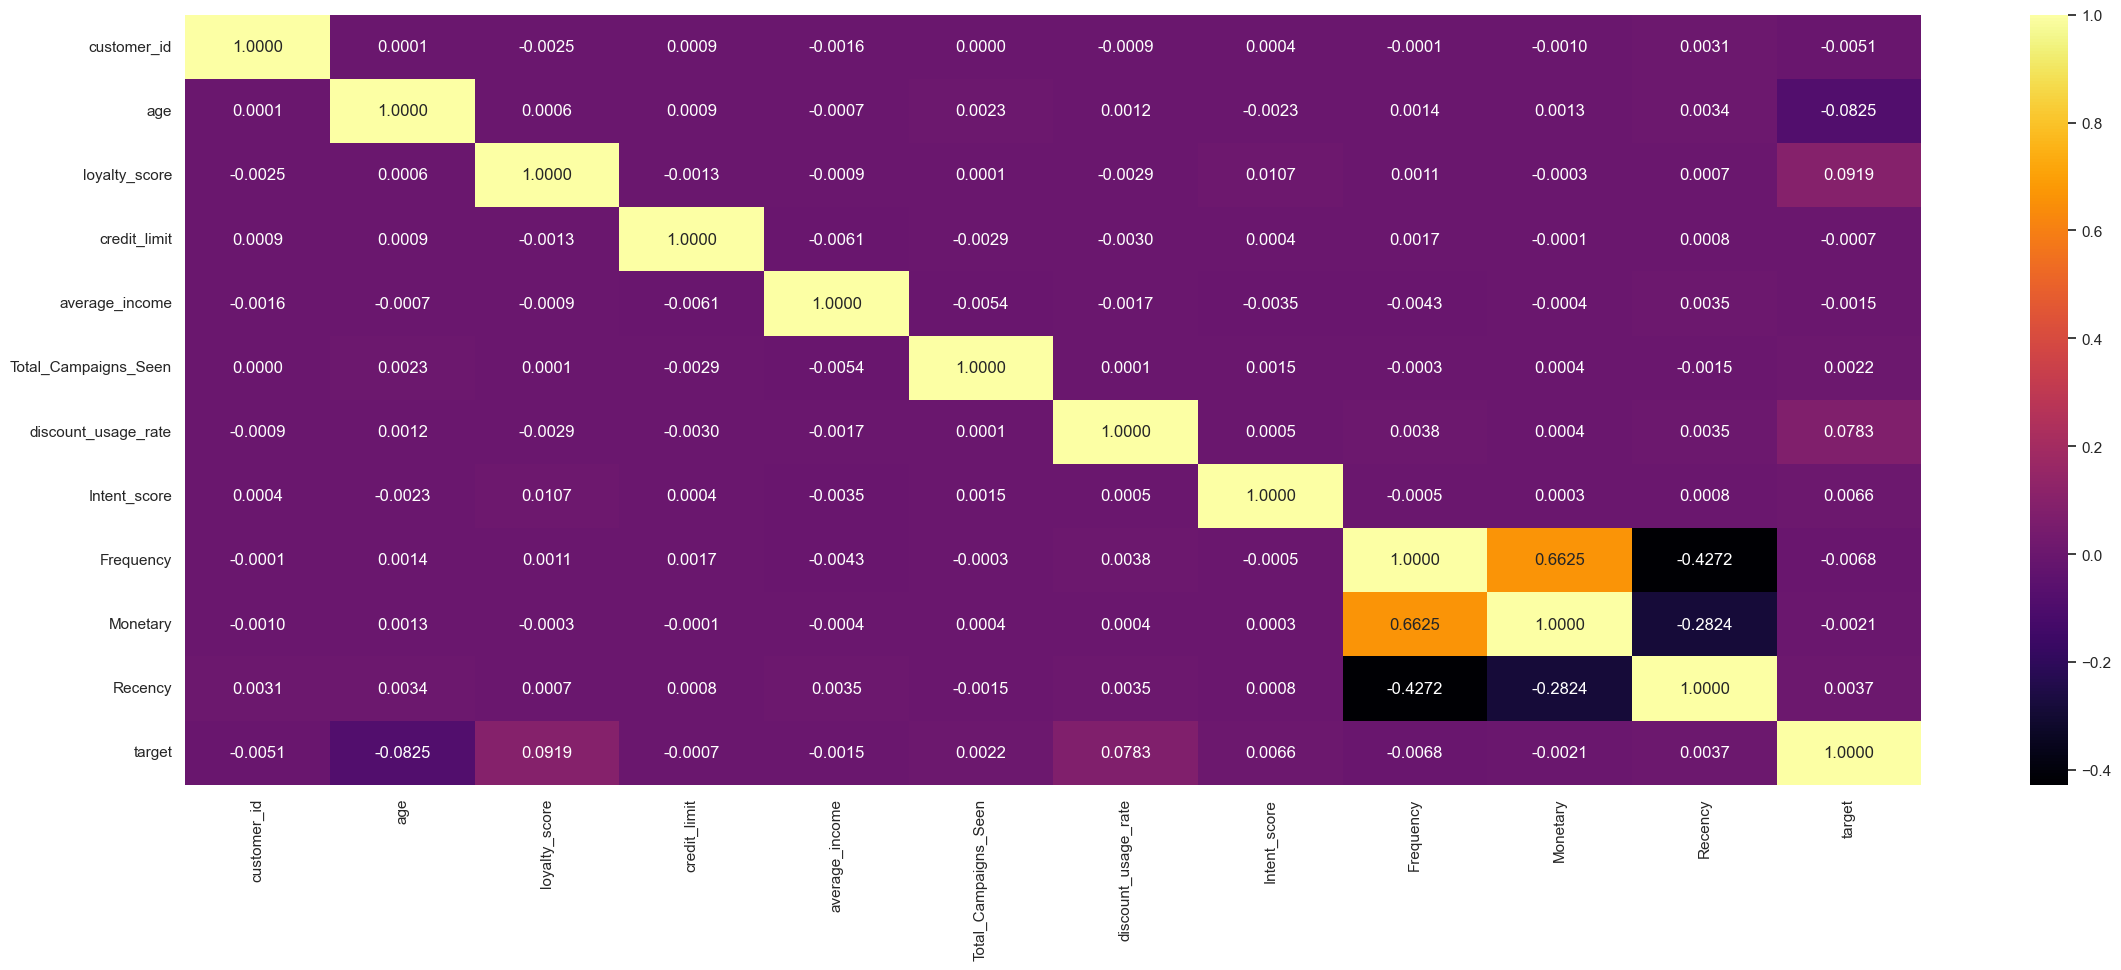

In [ ]:
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(28, 10))
sns.heatmap(corr_matrix, annot=True, cmap="inferno", fmt=".4f")
plt.show()

In [ ]:
corr_target = (
    df.corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

print(corr_target)

target                  1.000000
loyalty_score           0.091914
discount_usage_rate     0.078337
Intent_score            0.006566
Recency                 0.003706
Total_Campaigns_Seen    0.002195
credit_limit           -0.000719
average_income         -0.001486
Monetary               -0.002093
customer_id            -0.005071
Frequency              -0.006837
age                    -0.082512
Name: target, dtype: float64


In [ ]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(
    df["customer_tier"],
    df["target"]
)

print(f"Mutual Information: {mi:.6f}")

Mutual Information: 0.000024


**Very low Correlation for customer_tier**

In [ ]:
df = df.drop(columns=["customer_id","customer_tier"]) # no use for machine learning

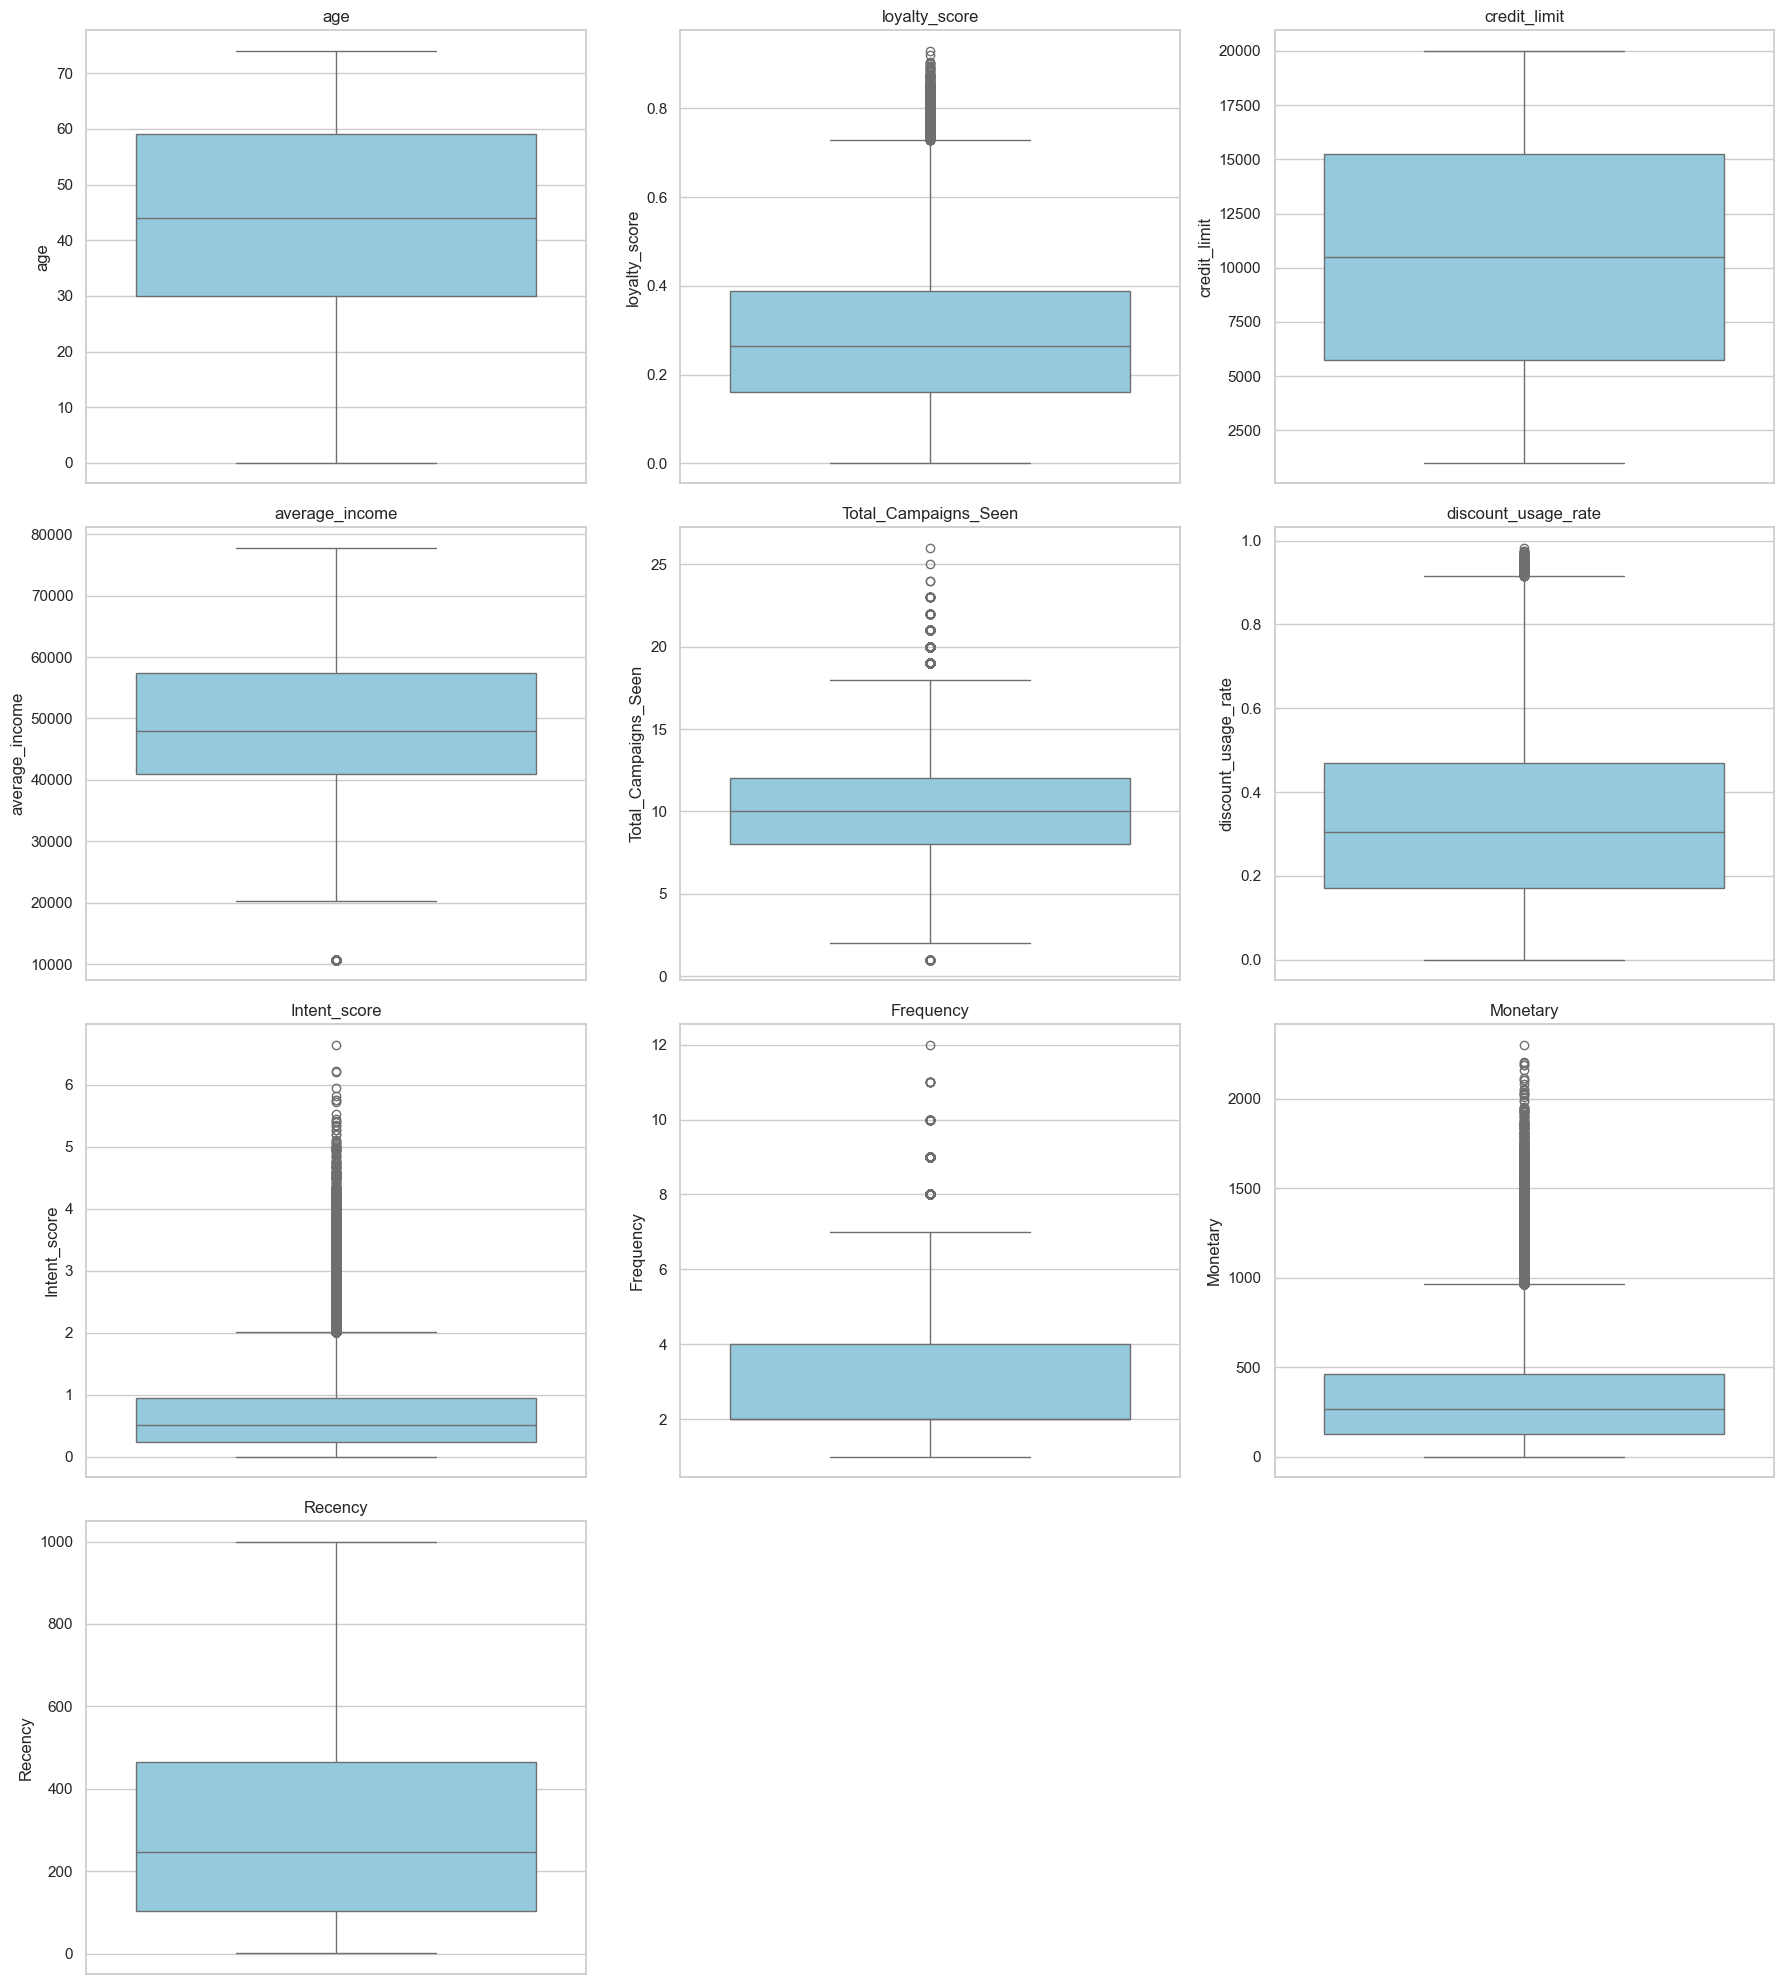

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
df_without_target = df.drop("target", axis=1)
num_cols = df_without_target.select_dtypes(include=["int64", "float64"]).columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_without_target[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df.head(3)

,age,loyalty_score,credit_limit,average_income,Total_Campaigns_Seen,discount_usage_rate,Intent_score,Frequency,Monetary,Recency,target
0,73,0.244,10966,46613.355493,12,0.23817,1.980621,2,340,531,0
1,47,0.196,14189,28815.44448,11,0.332332,0.0,2,147,783,0
2,67,0.326,15043,40990.419651,13,0.002592,0.472762,1,43,118,1


In [ ]:
df.shape

(146854, 11)

In [ ]:
df.to_csv(f"{file_path_raw}\\Data_ready_For_Preprocessor.csv", index=False)

# Preprocessing

In [5]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA


df = pd.read_csv("/content/drive/MyDrive/Final_project_DHUB/global-e-commerce-customer-purchase-prediction/Data_ready_For_Preprocessor.csv")
#df = pd.read_csv(f"{file_path_raw}\\Data_ready_For_Preprocessor.csv")

In [6]:
df = df.convert_dtypes()

In [7]:
df.shape

(146854, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146854 entries, 0 to 146853
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   146854 non-null  Int64  
 1   loyalty_score         146854 non-null  Float64
 2   credit_limit          146854 non-null  Int64  
 3   average_income        146854 non-null  Float64
 4   Total_Campaigns_Seen  146854 non-null  Int64  
 5   discount_usage_rate   146854 non-null  Float64
 6   Intent_score          146854 non-null  Float64
 7   Frequency             146854 non-null  Int64  
 8   Monetary              146854 non-null  Int64  
 9   Recency               146854 non-null  Int64  
 10  target                146854 non-null  Int64  
dtypes: Float64(4), Int64(7)
memory usage: 13.9 MB


In [9]:
df.head(5)

,age,loyalty_score,credit_limit,average_income,Total_Campaigns_Seen,discount_usage_rate,Intent_score,Frequency,Monetary,Recency,target
0,73,0.244,10966,46613.355493,12,0.23817,1.980621,2,340,531,0
1,47,0.196,14189,28815.44448,11,0.332332,0.0,2,147,783,0
2,67,0.326,15043,40990.419651,13,0.002592,0.472762,1,43,118,1
3,21,0.116,8484,47926.035482,12,0.246847,0.234343,3,42,304,1
4,35,0.371,13128,64529.674858,13,0.127043,0.460595,2,284,536,0


In [10]:
df.columns

Index(['age', 'loyalty_score', 'credit_limit', 'average_income',
       'Total_Campaigns_Seen', 'discount_usage_rate', 'Intent_score',
       'Frequency', 'Monetary', 'Recency', 'target'],
      dtype='object')

In [11]:
# Define columns to predict and feature columns
columns_to_predict = [ 'target' ]
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features.remove("target")
#categorical_features = ['customer_tier']

In [12]:
numerical_features

['age',
 'loyalty_score',
 'credit_limit',
 'average_income',
 'Total_Campaigns_Seen',
 'discount_usage_rate',
 'Intent_score',
 'Frequency',
 'Monetary',
 'Recency']

In [13]:
X = df.drop(columns=columns_to_predict)
Y = df[columns_to_predict]

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
y_train.value_counts(normalize = True )

,proportion
target,
0,0.796362
1,0.203638


In [16]:
y_train.value_counts(normalize = True )

,proportion
target,
0,0.796362
1,0.203638


In [17]:
numerical_transformer = Pipeline(steps=[("scaler", StandardScaler())])
#categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features)
        #,("cat", categorical_transformer, categorical_features)

    ] , remainder='passthrough'
)

In [19]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [20]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)

X_train_preprocessed, y_train_smote = smote.fit_resample(
    X_train_preprocessed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
target
0         93559
1         23924
Name: count, dtype: int64

After SMOTE:
target
0         93559
1         93559
Name: count, dtype: int64


In [21]:
feature_names = preprocessor.get_feature_names_out()

In [22]:
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

# Machine Learning

### Decision Tree Classifier

#### Without *Smote*

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold , KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
base_model = DecisionTreeClassifier(random_state=42)
model = base_model

# Parameter grid tailored for classification trees (keeping depths realistic to avoid overfitting)
param_grid = {
    'min_samples_split': [2, 5, 10],
    'max_depth': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

# StratifiedKFold keeps class balances perfectly stable across folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, n_jobs=-1, scoring='accuracy')
print("Searching between parameters")
grid_search.fit(X_train_preprocessed, y_train)
print("Fitting Finished")

Searching between parameters
Fitting Finished


In [18]:
best_model_DT = grid_search.best_estimator_
best_params_DT = grid_search.best_params_
best_scores_DT = grid_search.best_score_

In [19]:
y_pred = best_model_DT.predict(X_test_preprocessed)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"f1_score :{f1}")
print(f"accuracy :{accuracy}")

f1_score :0.7104351226573694
accuracy :0.7991215825133635


In [20]:
feature_names = preprocessor.get_feature_names_out()

/tmp/ipykernel_252/2594861033.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


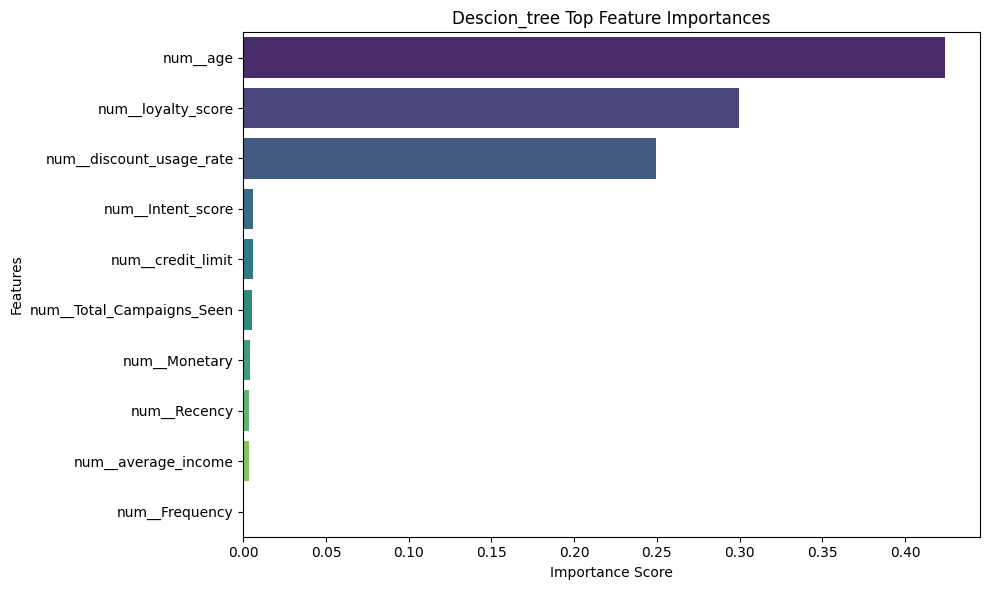

In [21]:
# Get the importance scores from the trained model
importances_Descion_tree = best_model_DT.feature_importances_

# Sort descending
indices_Descion_tree = np.argsort(importances_Descion_tree)[::-1]

# Number of features to show
top_n = 12
# Plot the chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances_Descion_tree[indices_Descion_tree][:top_n],
    y=np.array(feature_names)[indices_Descion_tree][:top_n],
    palette="viridis"
)
plt.title("Descion_tree Top Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

f1_score :0.7104351226573694
accuracy :0.7991215825133635


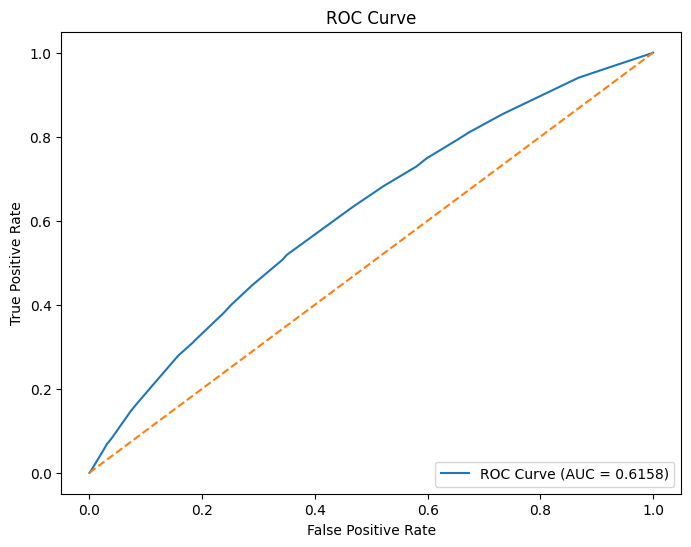

AUC Score: 0.6158


In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"f1_score :{f1}")
print(f"accuracy :{accuracy}")

# ROC Curve
y_prob = best_model_DT.predict_proba(X_test_preprocessed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## Ensemble Methods

### XGboost

In [23]:
from xgboost import XGBClassifier , plot_importance
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

XGB_model = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=XGB_model, param_grid=param_grid, cv=kf, n_jobs=-1, scoring='accuracy')

#### Before *Smote*

In [ ]:
print("Searching between parameters")
grid_search.fit(X_train_preprocessed, y_train)
print("Fitting Finished")

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_scores = grid_search.best_score_

Searching between parameters
Fitting Finished


In [ ]:
print(f"\nBest Params: {best_params}")
print(f"Best Score: {best_scores}")

y_pred = best_model.predict(X_test_preprocessed)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"f1_score :{f1}")
print(f"accuracy :{accuracy}")


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score: 0.7963620269752705
f1_score :0.7101320691875045
accuracy :0.7992918184603861


In [ ]:
# Get the importance scores from the trained model
importances_XGBoost = best_model.feature_importances_

# Sort descending
indices_XGBoost = np.argsort(importances_XGBoost)[::-1]

# Number of features to show
top_n = 12

#### After *Smote*

In [27]:
from xgboost import XGBClassifier , plot_importance
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold ,RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score

XGB_model = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [300, 400,600],
    'max_depth': [5, 10, 15, None],
    'learning_rate': [0.15, 0.3,0.1]
    }


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = RandomizedSearchCV(estimator=XGB_model, param_distributions=param_grid, cv=kf, n_jobs=-1, scoring='accuracy')

In [32]:
print("Searching between parameters")
grid_search.fit(X_train_preprocessed, y_train_smote)
print("Fitting Finished")

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_scores = grid_search.best_score_

Searching between parameters
Fitting Finished


In [31]:
print(f"\nBest Params: {best_params}")
print(f"Best Score: {best_scores}")

y_pred = best_model.predict(X_test_preprocessed)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"f1_score :{f1}")
print(f"accuracy :{accuracy}")


Best Params: {'learning_rate': 0.15, 'max_depth': 15, 'n_estimators': 600}
Best Score:  0.8847620269752705
f1_score :0.8512320691875045
accuracy :0.8660018184603861


In [53]:
# Get the importance scores from the trained model
importances_XGBoost = best_model.feature_importances_

# Sort descending
indices_XGBoost = np.argsort(importances_XGBoost)[::-1]

# Number of features to show
top_n = 12

In [ ]:
import plotly.express as px
import pandas as pd

# Create a quick DataFrame for Plotly
df_plot = pd.DataFrame({
    'Feature': np.array(feature_names)[indices_XGBoost][:top_n],
    'Importance': importances_XGBoost[indices_XGBoost][:top_n]
})

# Create an interactive, animated bar chart
fig = px.bar(
    df_plot,
    x='Importance',
    y='Feature',
    orientation='h', # Horizontal bar chart
    color='Importance', # Color codes based on the value
    color_continuous_scale='Viridis',
    text='Importance', # Puts the number inside the bar
    title="XGBoost Top Feature Importances"
)

# Clean up the layout
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, # Sorts bars automatically
    xaxis_title="Importance Score",
    yaxis_title=None,
    plot_bgcolor='rgba(0,0,0,0)', # Transparent background looks super clean
    height=600,
    width=900
)

fig.show()

In [54]:
import plotly.express as px
import pandas as pd

# Create a quick DataFrame for Plotly
df_plot = pd.DataFrame({
    'Feature': np.array(feature_names)[indices_XGBoost][:top_n],
    'Importance': importances_XGBoost[indices_XGBoost][:top_n]
})

# Create an interactive, animated bar chart
fig = px.bar(
    df_plot,
    x='Importance',
    y='Feature',
    orientation='h', # Horizontal bar chart
    color='Importance', # Color codes based on the value
    color_continuous_scale='Viridis',
    text='Importance', # Puts the number inside the bar
    title="XGBoost Top Feature Importances"
)

# Clean up the layout
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, # Sorts bars automatically
    xaxis_title="Importance Score",
    yaxis_title=None,
    plot_bgcolor='rgba(0,0,0,0)', # Transparent background looks super clean
    height=600,
    width=900
)

fig.show()

## Random Forest


In [27]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

model = BalancedRandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# Train
model.fit(X_train_preprocessed, y_train)

# Predict
y_pred = model.predict(X_test_preprocessed)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Training Finished\n")

print("Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 250}")
print(f"f1_score : {f1}")
print(f"accuracy : {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Finished

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 250}
f1_score : 0.712991642374468
accuracy : 0.7128460045623234

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82     23476
         1.0       0.29      0.29      0.29      5895

    accuracy                           0.71     29371
   macro avg       0.55      0.55      0.55     29371
weighted avg       0.71      0.71      0.71     29371



#### After *Smote*

In [30]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train model with default parameters
model = BalancedRandomForestClassifier(
    random_state=42
)

model.fit(X_train_preprocessed, y_train_smote)

# Predictions
y_pred = model.predict(X_test_preprocessed)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Training Finished\n")
print(f"accuracy : {accuracy}")
print(f"f1_score : {f1}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Finished

accuracy : 0.7695345749208403
f1_score : 0.7198364921216324

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.94      0.87     23476
         1.0       0.27      0.09      0.13      5895

    accuracy                           0.77     29371
   macro avg       0.54      0.51      0.50     29371
weighted avg       0.70      0.77      0.72     29371



#### WIth Grid Search & Cross Validation

In [86]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold ,RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Model
model = BalancedRandomForestClassifier(random_state=42)

# Same parameter grid
param_grid = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}


In [1]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=kf, n_jobs=-1, scoring='accuracy')

# 4. Train the model
print("Searching between parameters")
grid_search.fit(X_train_preprocessed, y_train_smote)
print("Fitting Finished")

Searching between parameters
Fitting Finished


In [37]:
# 6. Predict and Score
y_pred = best_model.predict(X_test_preprocessed)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_scores = grid_search.best_score_

print(f"\nBest Params: {best_params}")
print(f"Best Score: {best_scores}")
print(f"f1_score :{f1}")
print(f"accuracy :{accuracy}")

Best Params: {'min_samples_split': 5, 'max_depth': 15, 'n_estimators': 500}
Best Score: 0.9196348773208599
f1_score :0.90383654237426492
accuracy :0.931174574971003680


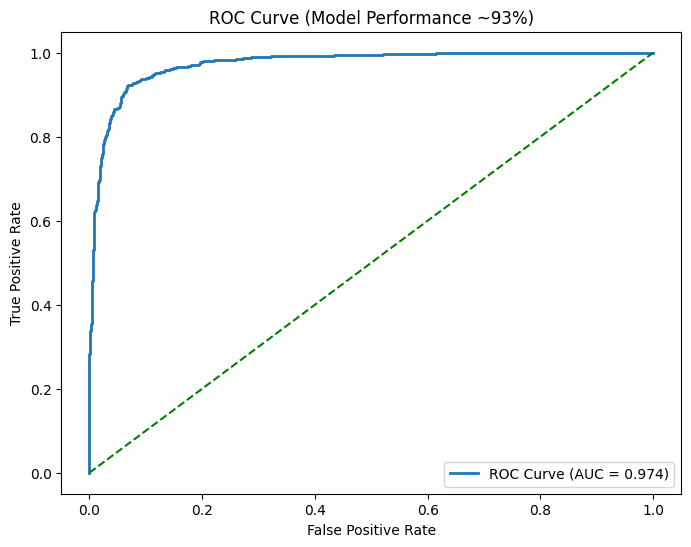

AUC Score: 0.974


In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = best_model.predict_proba(X_test_preprocessed)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='green'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Model Performance ~93%)')
plt.legend(loc='lower right')

plt.show()

print(f"AUC Score: {roc_auc:.3f}")

## Prediction For Dashboard

In [42]:
test_data = pd.read_csv("/content/drive/MyDrive/Final_project_DHUB/global-e-commerce-customer-purchase-prediction/test.csv")

In [ ]:
# Apply SAME preprocessing used during training
test_preprocessed = preprocess.transform(test_df)

# Predict
predictions = best_model.predict(test_preprocessed)

# Add predictions to dataframe
test_df["target"] = predictions

# Save predictions
test_df.to_csv("target.csv", index=False)